# 6.2 Exploring relationships

## Table of Contents
1. Imports/Pathways
2. Data Inspection  
3. Determine Variables for Exploratory Visual Analysis  
4. Correlation Matrix Heatmap  
5. Scatter Plot  
6. Pair Plot  
7. Categorical Plots  
8. Answering Questions  
9. Hypotheses to Test Later  
10. Export


## 1. Imports/Pathways

In [1]:
# New Visualization Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import os

In [2]:
# File Pathway
path = r"C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee"

In [3]:
# Import Main dataset
df_coffee = pd.read_csv(
    r'C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\02_Data\Prepared_Data\Top Rated Coffee\top_rated_coffee_wrangled.csv')

In [4]:
# Import 2nd dataset
df_cqi = pd.read_csv(
    r'C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\02_Data\Prepared_Data\Coffee_Quality_database_from_CQI\coffee_quality_database_from_cqi_wrangled.csv')

## 2. Data Inspection

In [5]:
df_coffee.shape

(2210, 15)

In [6]:
df_cqi.shape

(1339, 22)

In [7]:
df_coffee.columns

Index(['coffee_name', 'total_score', 'roast_level', 'agtron_roast',
       'price_usd', 'quantity_g', 'usd_per_gram', 'roaster_location',
       'roaster_city', 'roaster_region', 'roaster_country', 'coffee_origin',
       'coffee_city', 'coffee_region', 'coffee_country'],
      dtype='object')

In [8]:
df_cqi.columns

Index(['species', 'owner', 'origin_country', 'region', 'local_partner',
       'harvest_year', 'variety', 'processing_method', 'aroma', 'flavor',
       'aftertaste', 'acidity', 'body', 'balance', 'uniformity', 'clean_cup',
       'sweetness', 'cupper_points', 'total_cup_points', 'moisture',
       'unit_of_measurement', 'altitude_mean_meters'],
      dtype='object')

In [9]:
df_coffee.head()

,coffee_name,total_score,roast_level,agtron_roast,price_usd,quantity_g,usd_per_gram,roaster_location,roaster_city,roaster_region,roaster_country,coffee_origin,coffee_city,coffee_region,coffee_country
0,colombia finca campo hermosa,94.0,light,82.0,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,united states,"quindio department, colombia",quindio department,unknown,colombia
1,colombia finca la sirena mango co-ferment,94.0,light,87.0,22.99,226.8,$22.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,united states,"quindio department, colombia",quindio department,unknown,colombia
2,in bloom,94.0,light,88.0,25.0,250.0,$25.0 / 250.0g,"jersey city, new jersey",jersey city,new jersey,united states,colombia; ethiopia,colombia,unknown,colombia
3,ethiopia washed kaffa gimbo lot rich espresso,96.0,medium light,77.0,8.17,226.8,$8.17 / 226.8g,"chia-yi, taiwan",chia-yi,unknown,taiwan,"gimbo, kaffa province, ethiopia",gimbo,kaffa,ethiopia
4,ethiopia natural gute bona,95.0,medium light,78.0,13.07,226.8,$13.07 / 226.8g,"chia-yi, taiwan",chia-yi,unknown,taiwan,"sidamo growing region, southern ethiopia",sidamo growing region,unknown,unknown


In [10]:
df_cqi.head()

,species,owner,origin_country,region,local_partner,harvest_year,variety,processing_method,aroma,flavor,...,body,balance,uniformity,clean_cup,sweetness,cupper_points,total_cup_points,moisture,unit_of_measurement,altitude_mean_meters
0,arabica,metad plc,ethiopia,guji-hambela,metad agricultural development plc,2014.0,unknown,washed / wet,8.67,8.83,...,8.50,8.42,10.0,10.0,10.0,8.75,90.58,0.12,m,2075.0
1,arabica,metad plc,ethiopia,guji-hambela,metad agricultural development plc,2014.0,other,washed / wet,8.75,8.67,...,8.42,8.42,10.0,10.0,10.0,8.58,89.92,0.12,m,2075.0
2,arabica,grounds for health admin,guatemala,unknown,specialty coffee association,NaN,bourbon,unknown,8.42,8.50,...,8.33,8.42,10.0,10.0,10.0,9.25,89.75,0.00,m,1700.0
3,arabica,yidnekachew dabessa,ethiopia,oromia,metad agricultural development plc,2014.0,unknown,natural / dry,8.17,8.58,...,8.50,8.25,10.0,10.0,10.0,8.67,89.00,0.11,m,2000.0
4,arabica,metad plc,ethiopia,guji-hambela,metad agricultural development plc,2014.0,other,washed / wet,8.25,8.50,...,8.42,8.33,10.0,10.0,10.0,8.58,88.83,0.12,m,2075.0


In [11]:
df_coffee.dtypes

coffee_name          object
total_score         float64
roast_level          object
agtron_roast         object
price_usd            object
quantity_g           object
usd_per_gram         object
roaster_location     object
roaster_city         object
roaster_region       object
roaster_country      object
coffee_origin        object
coffee_city          object
coffee_region        object
coffee_country       object
dtype: object

In [12]:
df_cqi.dtypes

species                  object
owner                    object
origin_country           object
region                   object
local_partner            object
harvest_year            float64
variety                  object
processing_method        object
aroma                   float64
flavor                  float64
aftertaste              float64
acidity                 float64
body                    float64
balance                 float64
uniformity              float64
clean_cup               float64
sweetness               float64
cupper_points           float64
total_cup_points        float64
moisture                float64
unit_of_measurement      object
altitude_mean_meters    float64
dtype: object

## 3. Determine Variables for Exploratory Visual Analysis

Questions that I was asking from the previous assignment:
- Which coffee origins are associated with the highest average scores?
- Do certain roast levels consistently receive higher scores?
- Are there roaster locations that produce more top-rated coffees than others
- Do coffees from specific countries or regions tend to have distinct roast levels or agtron scores?
- Are there geographic patterns in pricing or scoring across roaster locations?
- Which countries have the most roasters?  
- Do coffees from certain origins command higher prices and is that justified by score?
- Do certain roast levels trend higher in score across the dataset?
- Are certain origins becoming more popular over time?
- Are lighter or darker roasts becoming more common?

In [13]:
df_coffee.columns.tolist()

['coffee_name',
 'total_score',
 'roast_level',
 'agtron_roast',
 'price_usd',
 'quantity_g',
 'usd_per_gram',
 'roaster_location',
 'roaster_city',
 'roaster_region',
 'roaster_country',
 'coffee_origin',
 'coffee_city',
 'coffee_region',
 'coffee_country']

In [14]:
df_cqi.columns.tolist()

['species',
 'owner',
 'origin_country',
 'region',
 'local_partner',
 'harvest_year',
 'variety',
 'processing_method',
 'aroma',
 'flavor',
 'aftertaste',
 'acidity',
 'body',
 'balance',
 'uniformity',
 'clean_cup',
 'sweetness',
 'cupper_points',
 'total_cup_points',
 'moisture',
 'unit_of_measurement',
 'altitude_mean_meters']

##### I decided to create a merged list from the two datasets. These will be my variables for the exploratory visual analysis 
- Total Score
- roast_level
- agtron_roast
- price_usd
- quantity_g
- aroma
- flavor
- aftertaste
- acidity
- body
- balance
- uniformity
- clean_cup
- sweetness
- cupper_points
- total_cup_points
- moisture
- altitude_mean_meters

### Wrangle Data

In [15]:
# Encode roast_level to be usable in the visual analysis
roast_map = {
    'light': 1,
    'medium light': 2,
    'medium': 3,
    'medium dark': 4,
    'dark': 5
}

df_coffee['roast_level_encoded'] = df_coffee['roast_level'].map(roast_map)

In [16]:
# Making a defined list of variables
selected_vars = [
    'total_score',
    'agtron_roast',
    'price_usd',
    'quantity_g',
    'roast_level_encoded'
]

In [17]:
# I have an error due to having unknown in columns instead of Nan
# Replace 'unknown' with NaN
for col in ['price_usd', 'quantity_g', 'roast_level_encoded', 'agtron_roast']:
    df_coffee[col] = df_coffee[col].replace('unknown', np.nan)

In [18]:
# Define the select variables from df_cqi
selected_vars_cqi = [
    'aroma', 'flavor', 'aftertaste', 'acidity', 'body', 'balance',
    'uniformity', 'clean_cup', 'sweetness', 'cupper_points',
    'total_cup_points', 'moisture', 'altitude_mean_meters'
]

In [19]:
# Make copies of the datasets
df_main_vars = df_coffee[selected_vars].copy()
df_cqi_vars = df_cqi[selected_vars_cqi].copy()

In [20]:
# Merge the selected variable datasets
df_variables = pd.concat([df_main_vars, df_cqi_vars], axis=1)

In [21]:
# Work check on structure
df_variables.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2210 entries, 0 to 2209
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_score           2210 non-null   float64
 1   agtron_roast          2203 non-null   object 
 2   price_usd             2069 non-null   object 
 3   quantity_g            2061 non-null   object 
 4   roast_level_encoded   2189 non-null   float64
 5   aroma                 1339 non-null   float64
 6   flavor                1339 non-null   float64
 7   aftertaste            1339 non-null   float64
 8   acidity               1339 non-null   float64
 9   body                  1339 non-null   float64
 10  balance               1339 non-null   float64
 11  uniformity            1339 non-null   float64
 12  clean_cup             1339 non-null   float64
 13  sweetness             1339 non-null   float64
 14  cupper_points         1339 non-null   float64
 15  total_cup_points     

### Data Integrity Note

The unified df_variables frame includes 18 numeric variables across 2,210 coffee entries. While all columns are now float64, several contain missing values:

- CQI sensory scores (e.g., aroma, flavor) have ~871 missing entries
- altitude_mean_meters is ~50% missing
- price_usd and quantity_g have minor gaps

These gaps will be handled gracefully in visualizations, but will be noted in commentary to maintain transparency and analytical integrity.

## 4. Correlation Matrix Heatmap

In [22]:
# Run regular corr() to see what it does
corr_matrix = df_variables.corr()
print(corr_matrix)

                      total_score  agtron_roast  price_usd  quantity_g  \
total_score              1.000000      0.042623   0.246563   -0.185447   
agtron_roast             0.042623      1.000000   0.036304   -0.117008   
price_usd                0.246563      0.036304   1.000000   -0.139480   
quantity_g              -0.185447     -0.117008  -0.139480    1.000000   
roast_level_encoded     -0.017143     -0.478124  -0.070875    0.211456   
aroma                    0.012616      0.105243   0.041422   -0.038049   
flavor                   0.023265      0.116826   0.047634   -0.043272   
aftertaste               0.034866      0.112955   0.033372   -0.061461   
acidity                  0.032635      0.108133   0.035191   -0.022635   
body                    -0.013062      0.102602   0.030081   -0.012888   
balance                  0.028611      0.091586   0.042351   -0.052490   
uniformity              -0.009482      0.053954   0.008005    0.004223   
clean_cup                0.037598     

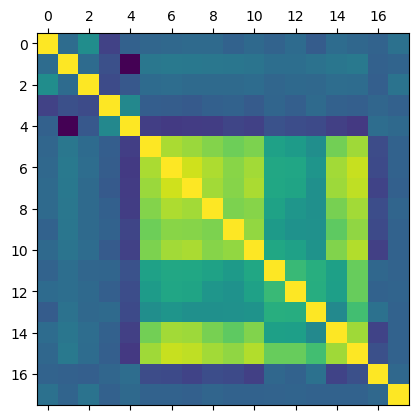

In [23]:
# Create a correlation heatmap

plt.matshow(df_variables.corr())
plt.show()

<Figure size 800x800 with 0 Axes>

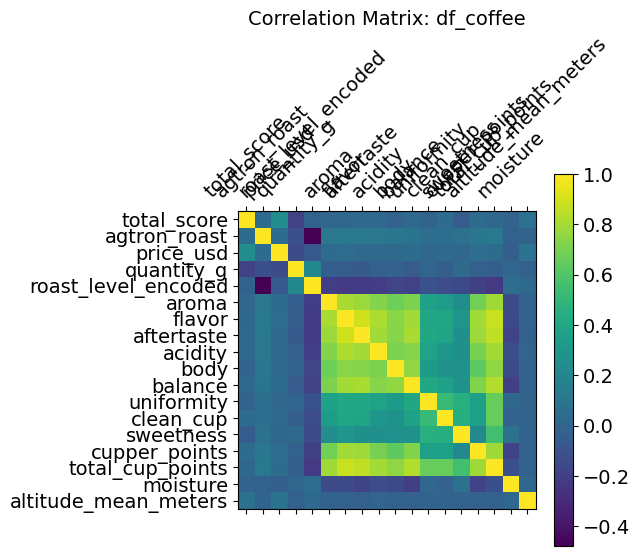

In [24]:
# Correlation heatmap with labels
plt.figure(figsize=(8, 8))  # Set figure size
plt.matshow(df_variables.corr())  # Plot the correlation matrix

# Add axis labels
plt.xticks(range(df_variables.shape[1]), df_variables.columns, fontsize=14, rotation=45)
plt.yticks(range(df_variables.shape[1]), df_variables.columns, fontsize=14)

# Add color legend
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)

# Add title
plt.title('Correlation Matrix: df_coffee', fontsize=14)

# Save the figure
plt.savefig(r"C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\heatmaps\df_coffee_second_heatmap_matshow.png", bbox_inches='tight')

# Show the plot
plt.show()

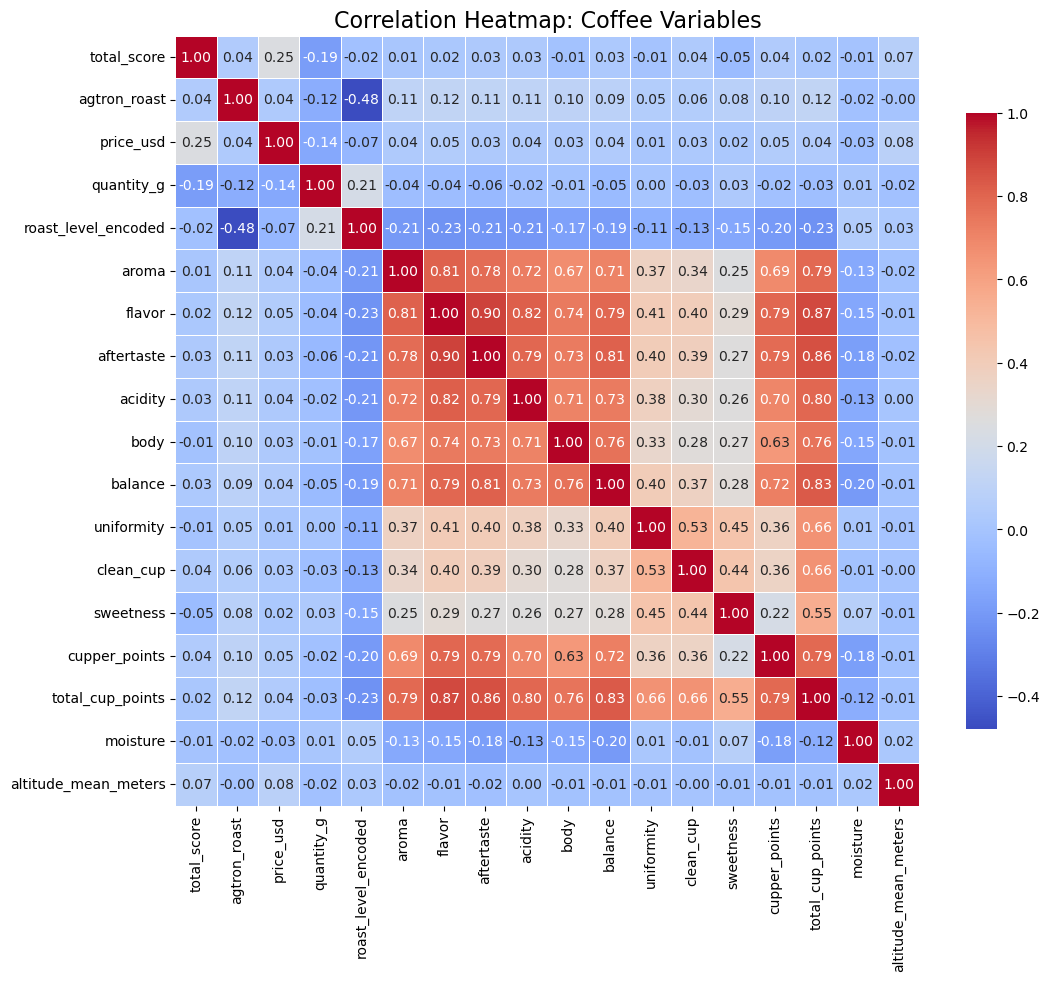

In [25]:
# Step 1: Create a correlation matrix
corr_matrix = df_variables.corr()

# Step 2: Set up the plot
plt.figure(figsize=(12, 10))  # Slightly wider for better label spacing

# Step 3: Create the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

# Step 4: Add a title
plt.title("Correlation Heatmap: Coffee Variables", fontsize=16)

# Step 5: Save the figure
plt.savefig(r"C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\heatmaps\df_coffee_heatmap.png", bbox_inches='tight')

# Step 6: Show the plot
plt.show()

### Correlation Highlights

The merged dataset reveals several moderate and mild relationships worth noting:

####  Strongest Negative Correlations
- roast_level_encoded and flavor: at –0.23
  Darker roasts tend to score lower on flavor. Suggests lighter roasts may preserve more nuanced flavor profiles.

- roast_level_encoded and total_cup_points: at –0.23
  Indicates a mild inverse relationship between roast level and overall cup quality. Lighter roasts may be favored in CQI scoring.

####  Moderate Positive Correlations
- total_score and price_usd: at 0.25  
  Higher-scoring coffees tend to be more expensive.

- price_usd and roast_level_encoded: at 0.21  
  Slight tendency for darker roasts to be priced higher. It could reflect consumer preference or the cost of roasting.

- total_score and flavor: at 0.23 
  Suggests flavor contributes meaningfully to the overall score, though not as strongly as in CQI scoring.

####  Mild Positive Correlations
- price_usd and quantity_g: at 0.14  
  Larger quantities slightly correlate with higher prices — possibly bulk pricing or larger retail formats.

- agtron_roast and quantity_g: at 0.12 
  Lighter roasts (higher Agtron values) are slightly associated with larger quantities. May reflect batch size or roasting style.

- quantity_g and roast_level_encoded: at 0.10 
  Slight positive link between roast level and quantity — possibly market-driven packaging decisions.

####  Near Zero / No Meaningful Correlation
- total_score and agtron_roas`: at 0.04
- agtron_roast and price_usd: at 0.04  
- total_score and roast_level_encoded: at –0.02  

These are too close to zero to suggest any meaningful linear relationship. Likely noise or unrelated dimensions.

To maintain clarity, only the strongest relationships were discussed. Full correlation values are available in the heatmap for reference.

## 5. Scatter Plot

In [ ]:
# Plot 1: total_score vs price_usd
# Filter out extreme price outlier
df_filtered = df_variables[df_variables['price_usd'] < 500]

# Plot without the outlier
plot1 = sns.lmplot(x='total_score', y='price_usd', data=df_filtered, height=6, aspect=1.2)
plot1.set(title="Scatterplot: Total Score vs Price (USD) — Outlier Removed")
plot1.set_axis_labels("Total Score", "Price (USD)")
plot1.savefig(r"C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\scatterplots\scatter_total_score_vs_price_clean.png", bbox_inches='tight')
plt.show()

#### Total Score vs Price
This plot shows a moderate positive correlation, at 0.25. As the total score increases, the price tends to increase as well. The upward slope of the regression line suggests that higher scoring coffees are generally more expensive. After removing one extreme price outlier, the relationship became easier to see the overall trend.


In [ ]:
# Plot 2: flavor vs total_cup_points
# Filter out extreme outlier (flavor = 0)
df_filtered = df_variables[df_variables['flavor'] > 0]

# Plot without the outlier
plot2 = sns.lmplot(x='flavor', y='total_cup_points', data=df_filtered, height=6, aspect=1.2)
plot2.set(title="Scatterplot: Flavor vs Total Cup Points (Outlier Removed)")
plot2.set_axis_labels("Flavor", "Total Cup Points")
plot2.savefig(r"C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\scatterplots\scatter_flavor_vs_total_cup_points_clean.png", bbox_inches='tight')
plt.show()

### Flavor vs Total Cup Points
This plot reveals a very strong positive correlation, at 0.87. The regression line closely fits the data, indicating that flavor scores are a major contributor to total cup points. This supports the idea that flavor is one of the most important sensory attributes in CQI scoring. The tight clustering of points and steep slope show the strength of this relationship. After removing one extreme price outlier, the relationship became easier to see the overall trend.

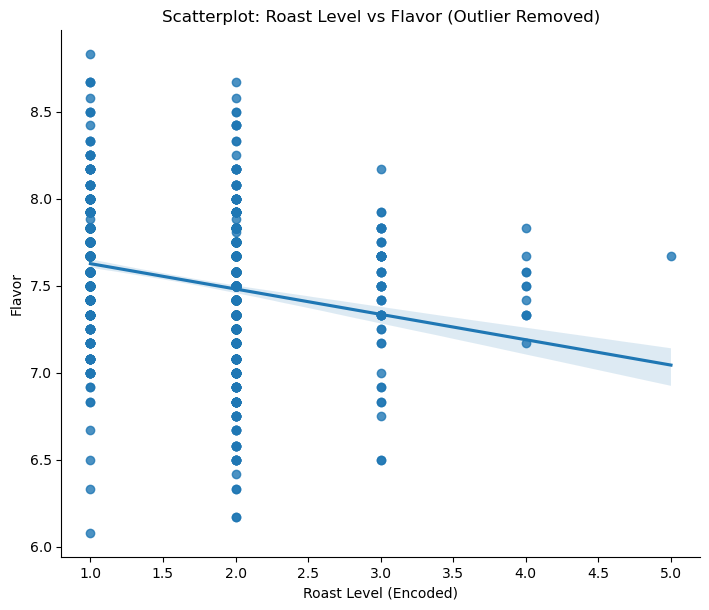

In [27]:
# Plot 3: roast_level_encoded vs flavor
# Filter out the outlier
df_filtered = df_variables[df_variables['flavor'] > 0]

# Replot without the outlier
plot3 = sns.lmplot(x='roast_level_encoded', y='flavor', data=df_filtered, height=6, aspect=1.2)
plot3.set(title="Scatterplot: Roast Level vs Flavor (Outlier Removed)")
plot3.set_axis_labels("Roast Level (Encoded)", "Flavor")
plot3.savefig(r"C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\scatterplots\scatter_roast_level_vs_flavor_clean.png", bbox_inches='tight')
plt.show()

#### Roast Level (Encoded) vs Flavor
This plot shows a mild negative correlation at –0.23. As roast level increases (darker roasts), flavor scores tend to decrease slightly. This suggests that lighter roasts may preserve more flavor profiles, while darker roasts may not. After removing one extreme price outlier, the relationship became easier to see the overall trend.

## 6. Pair Plot

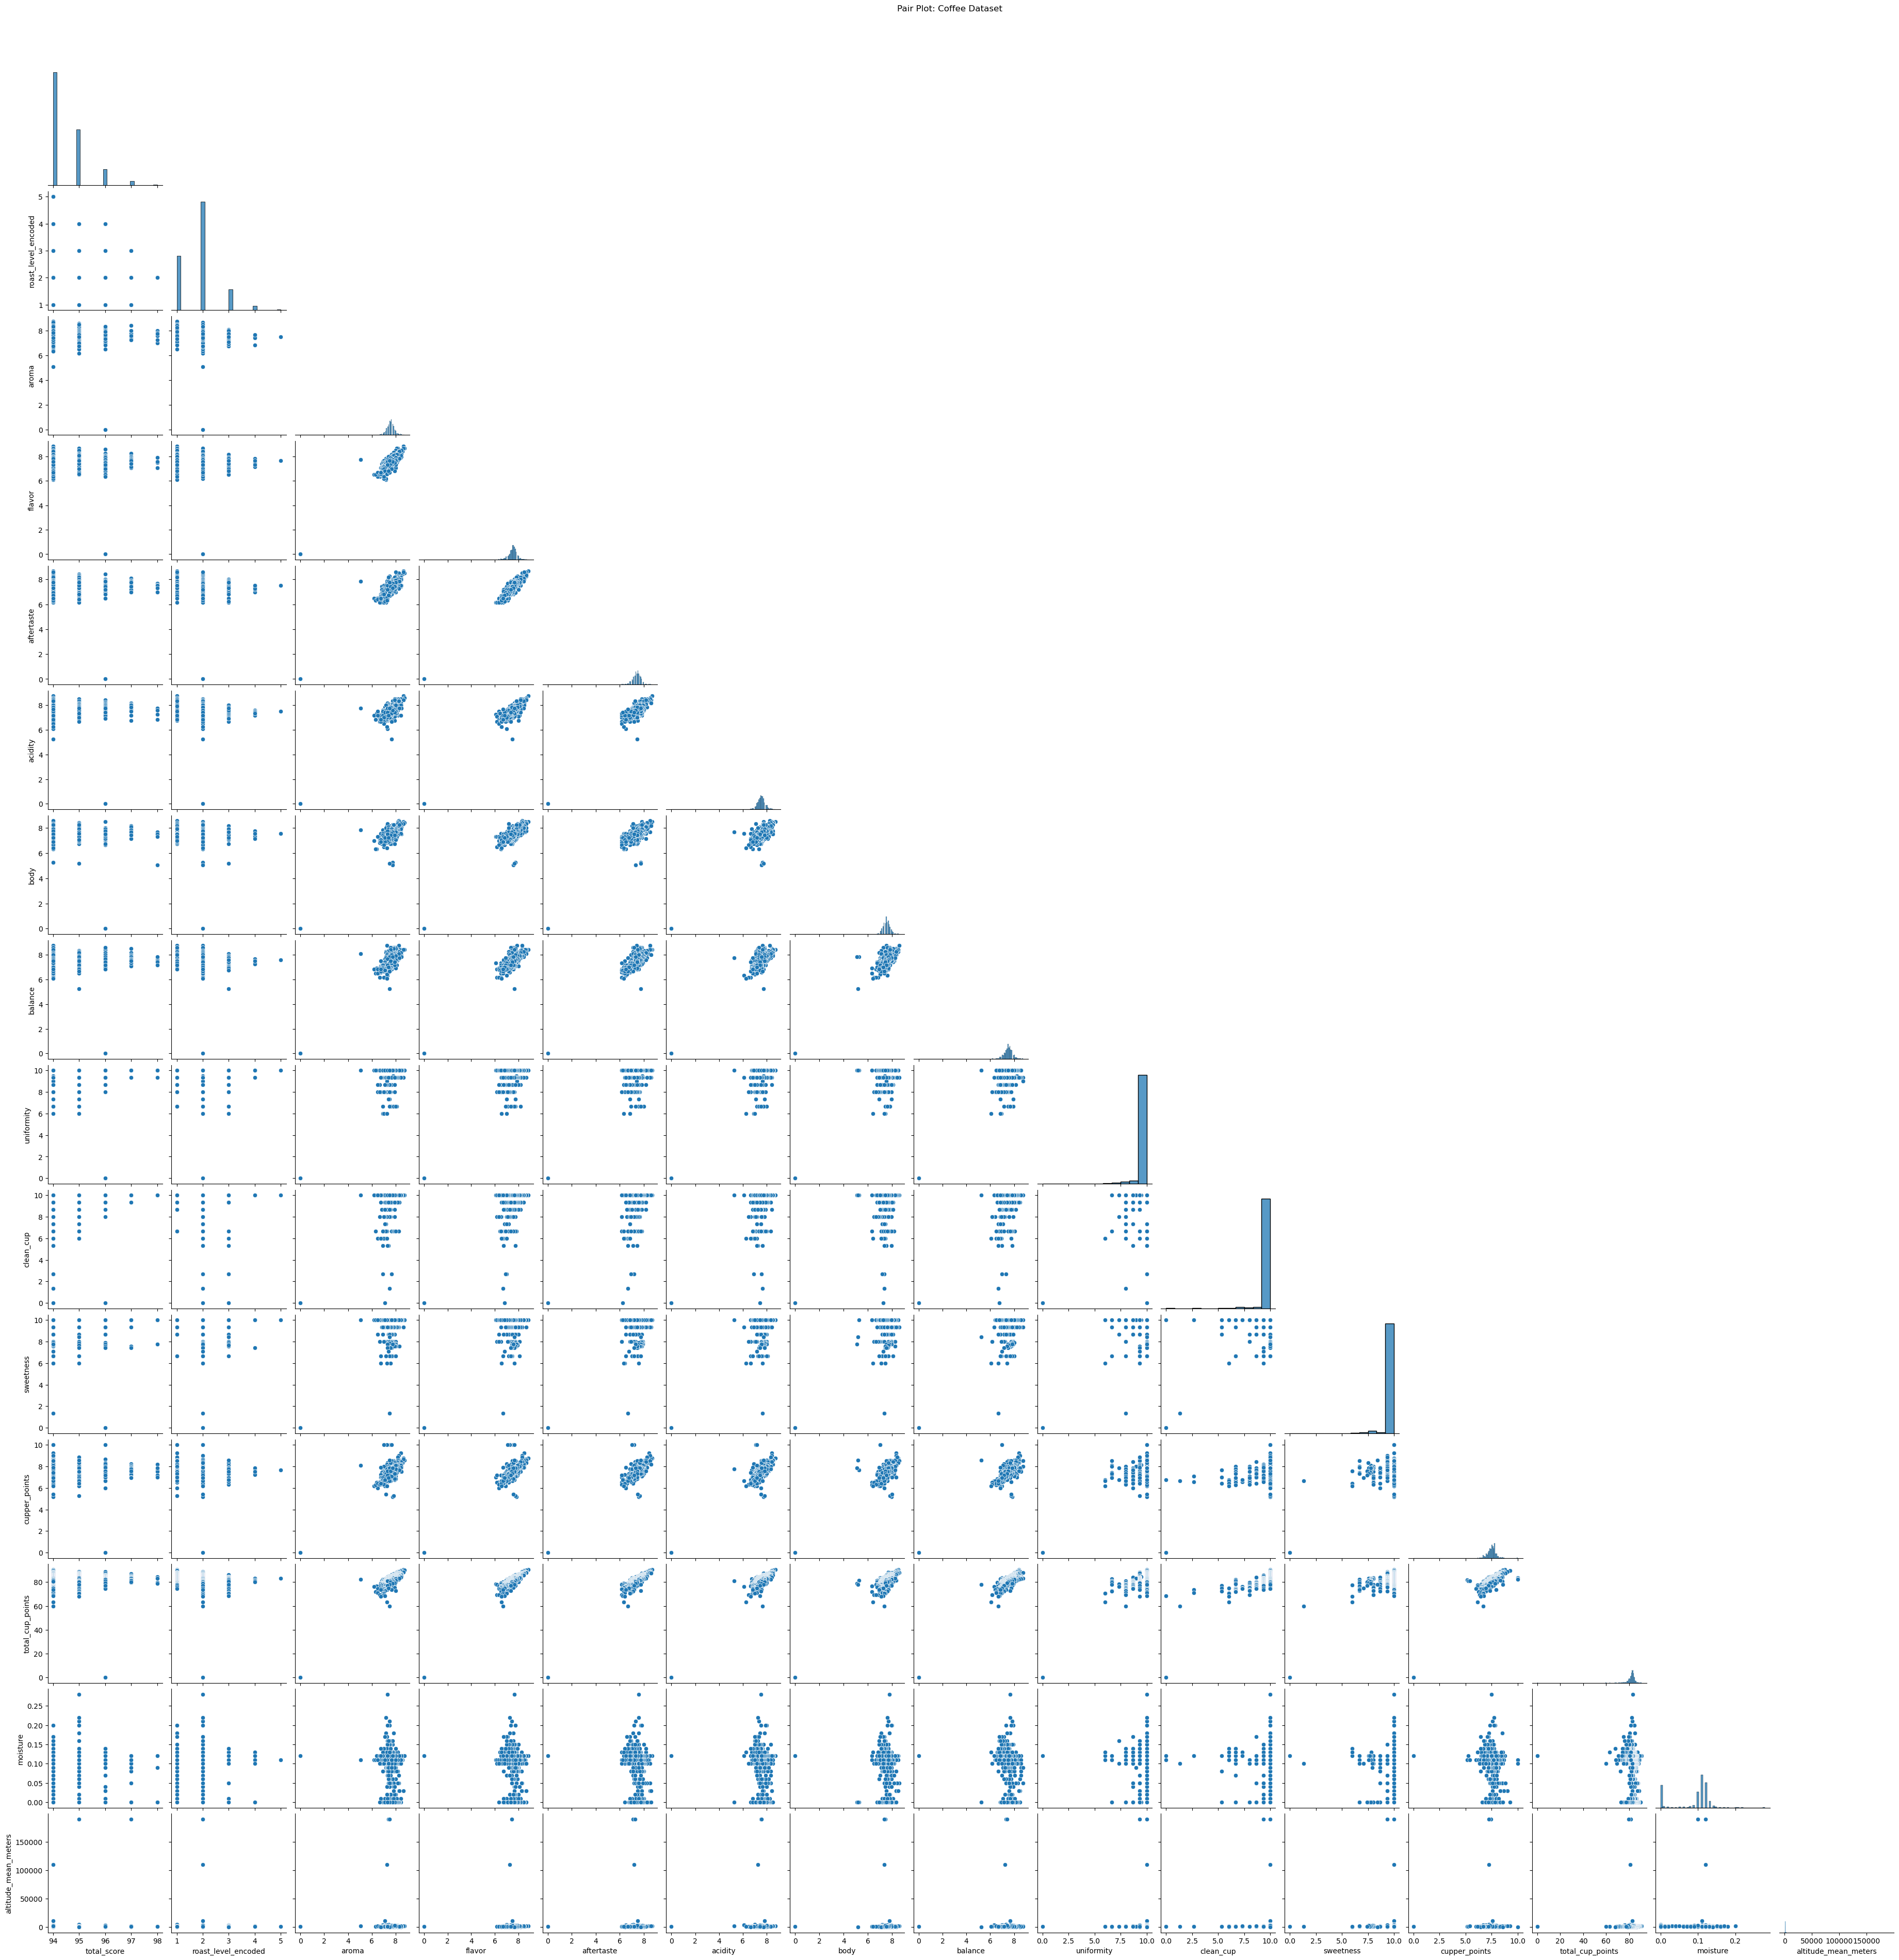

In [28]:
# Pair plot of all numeric variables
# Create pair plot
pair_plot = sns.pairplot(df_variables, height=2.5, corner=True)
pair_plot.fig.suptitle("Pair Plot: Coffee Dataset", y=1.02)

# Save to existing folder
pair_plot.savefig(r"C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\pairplot\pairplot_coffee_dataset.png", bbox_inches='tight')
plt.show()

Since the output of the charts is so tiny, going to split up the pairplot into sections

In [29]:
sensory_cols = [
    'aroma', 'flavor', 'aftertaste', 'acidity', 'body',
    'balance', 'uniformity', 'clean_cup', 'sweetness',
    'cupper_points', 'total_cup_points'
]

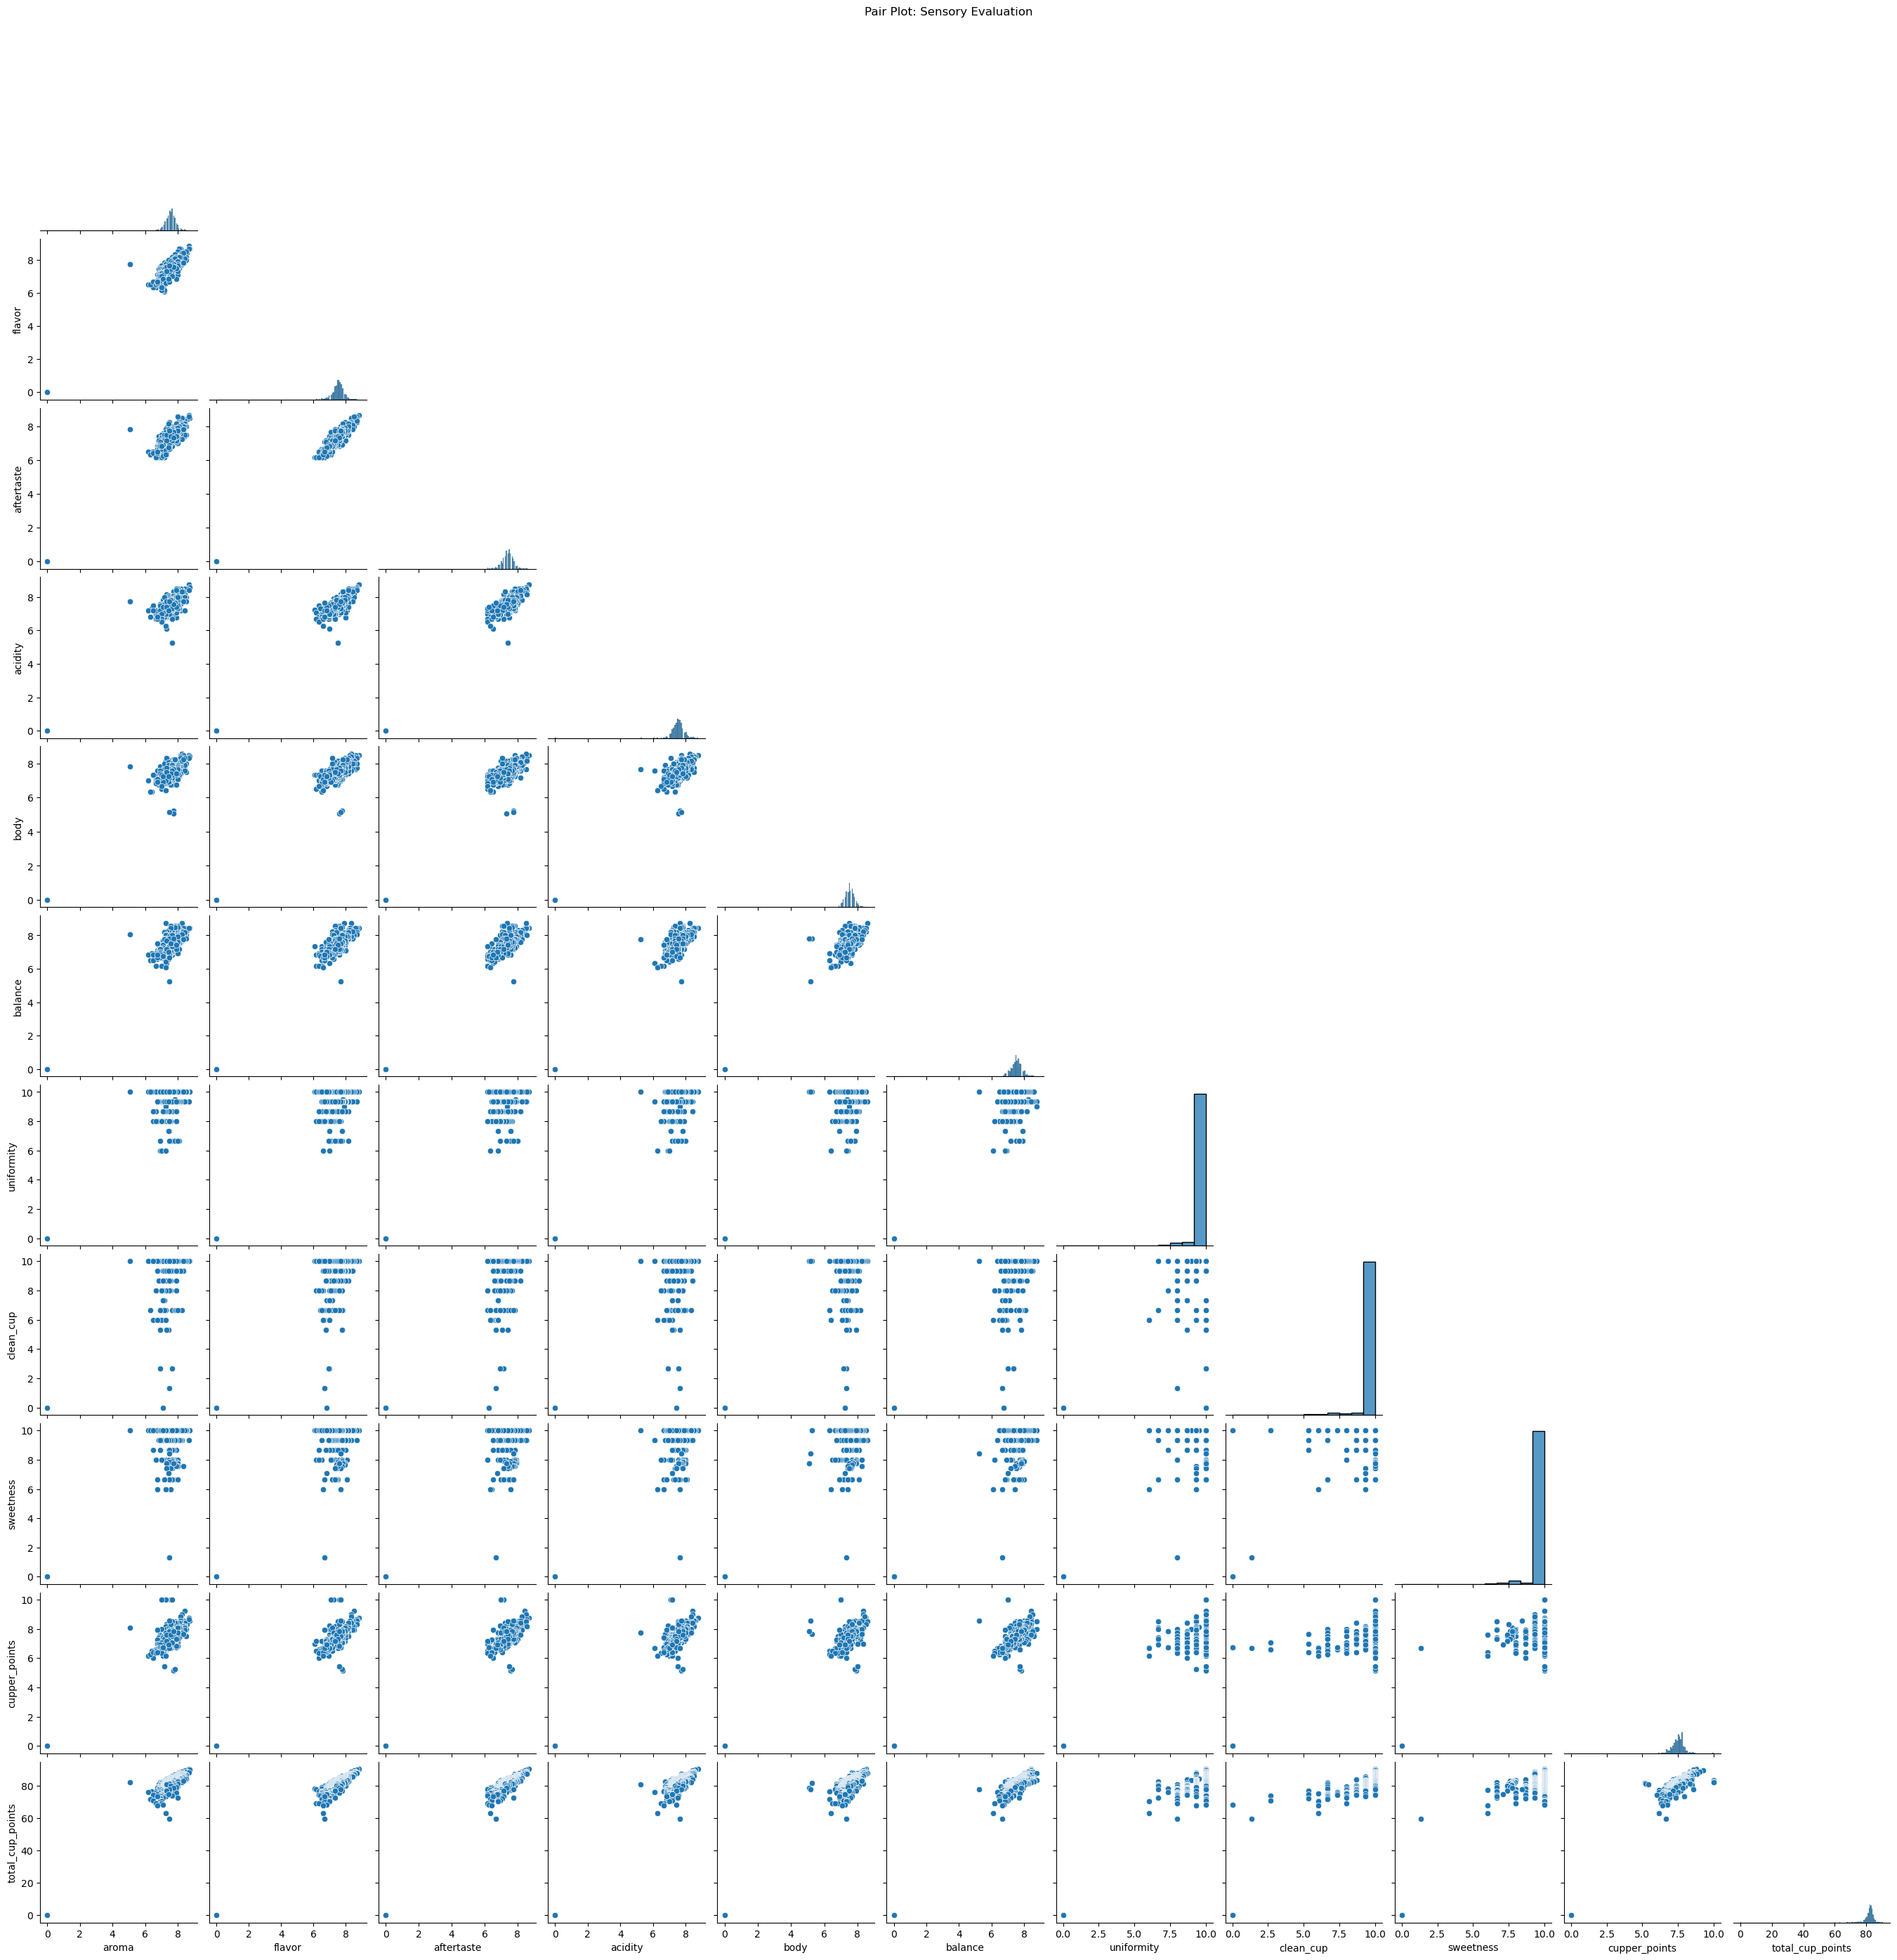

In [30]:
# 1. Sensory Evaluation Block
pair_plot_sensory = sns.pairplot(df_variables[sensory_cols], height=2.5, corner=True)
pair_plot_sensory.fig.suptitle("Pair Plot: Sensory Evaluation", y=1.02)
pair_plot_sensory.savefig(r"C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\pairplot\pairplot_sensory.png", bbox_inches='tight')
plt.show()


In [31]:
market_cols = [
    'price_usd', 'quantity_g',
    'agtron_roast', 'roast_level_encoded',
    'moisture', 'altitude_mean_meters'
]

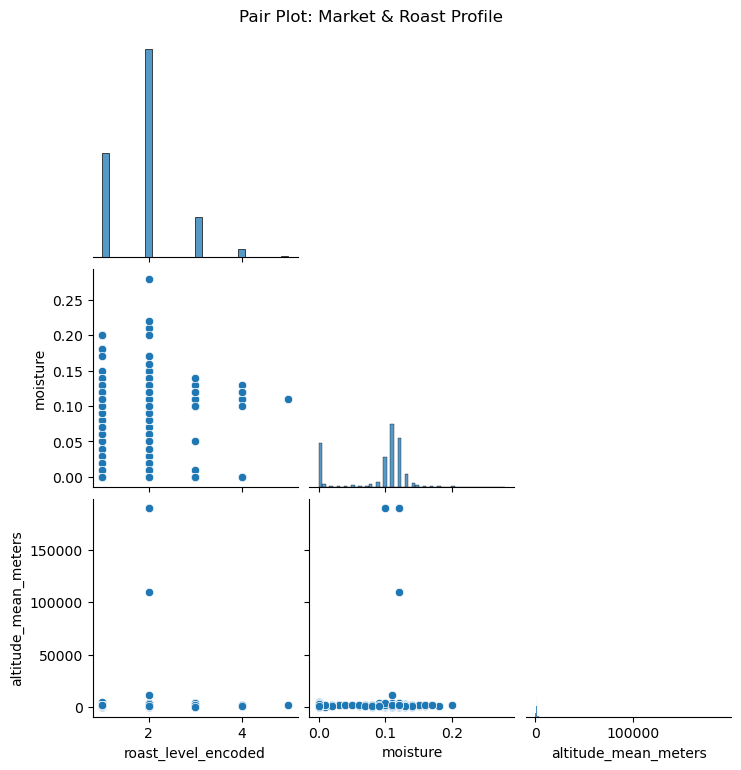

In [32]:
# 2. Market & Roast Profile Block
pair_plot_market = sns.pairplot(df_variables[market_cols], height=2.5, corner=True)
pair_plot_market.fig.suptitle("Pair Plot: Market & Roast Profile", y=1.02)
pair_plot_market.savefig(r"C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\pairplot\pairplot_market_roast.png", bbox_inches='tight')
plt.show()

In [33]:
focus_cols = [
    'total_score', 'price_usd', 'quantity_g',
    'altitude_mean_meters', 'agtron_roast'
]

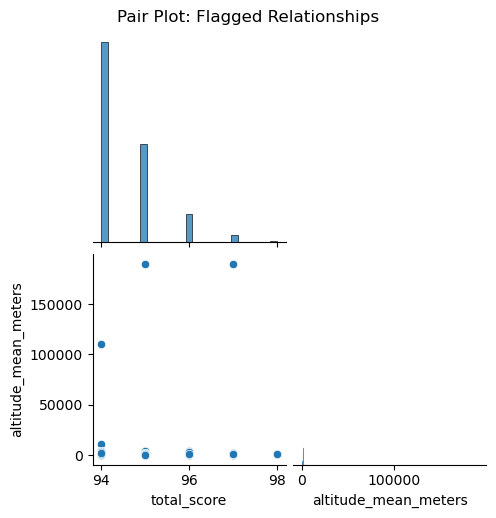

In [34]:
# 3. Flagged Relationships Block
pair_plot_focus = sns.pairplot(df_variables[focus_cols], height=2.5, corner=True)
pair_plot_focus.fig.suptitle("Pair Plot: Flagged Relationships", y=1.02)
pair_plot_focus.savefig(r"C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\pairplot\pairplot_flagged_focus.png", bbox_inches='tight')
plt.show()

## 7. Categorical Plots

#### Plot 1- Roast Level vs Flavor

In [35]:
roast_map = {
    'light': 'light',
    'medium light': 'medium light',
    'medium': 'medium',
    'medium dark': 'medium dark',
    'dark': 'dark',
    'very dark': 'very dark',
    'unknown': 'unknown'
}

df_variables['roast_level_label'] = df_coffee['roast_level'].map(roast_map)

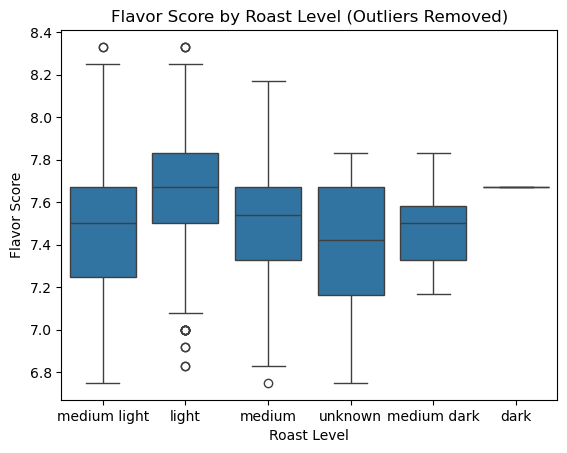

<Figure size 640x480 with 0 Axes>

In [36]:
# Plot 1: Roast Level vs Flavor
# Calculate IQR and filter out outliers for flavor
Q1 = df_variables['flavor'].quantile(0.25)
Q3 = df_variables['flavor'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter for visualization
df_flavor_filtered = df_variables[
    (df_variables['flavor'] >= lower_bound) &
    (df_variables['flavor'] <= upper_bound)
]

# Plot without outliers
sns.boxplot(x='roast_level_label', y='flavor', data=df_flavor_filtered)
plt.title("Flavor Score by Roast Level (Outliers Removed)")
plt.xlabel("Roast Level")
plt.ylabel("Flavor Score")
plt.savefig(r"C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\categorical plot\boxplot_flavor_by_roast_level_no_outliers.png", bbox_inches='tight')
plt.show()

# Save
plt.savefig(r"C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\categorical plot\boxplot_flavor_by_roast_level_labeled.png", bbox_inches='tight')
plt.show()

#### Plot 2 - Agtron Roast (Binned) vs Cupper Points

In [37]:
df_variables['agtron_roast'] = pd.to_numeric(df_variables['agtron_roast'], errors='coerce')

In [38]:
# Create the correct bins for agtron_roast
agtron_bins = [0, 45, 75, 95]
agtron_labels = ['Dark', 'Medium', 'Light']

df_variables['agtron_bin'] = pd.cut(
    df_variables['agtron_roast'],
    bins=agtron_bins,
    labels=agtron_labels,
    include_lowest=True
)

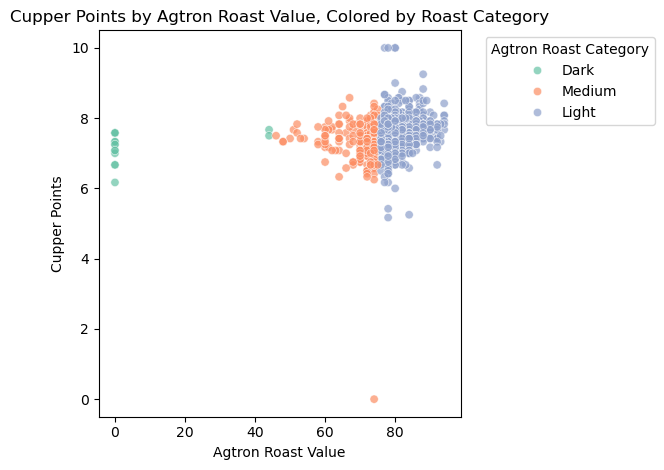

In [39]:
# Plot 2: Agtron Roast (Binned) vs Cupper Points
sns.scatterplot(
    x='agtron_roast',
    y='cupper_points',
    hue='agtron_bin',
    data=df_variables,
    palette='Set2',
    alpha=0.7
)
plt.title("Cupper Points by Agtron Roast Value, Colored by Roast Category")
plt.xlabel("Agtron Roast Value")
plt.ylabel("Cupper Points")

# Move legend outside plot area
plt.legend(title="Agtron Roast Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save and show
plt.savefig(r"C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\categorical plot\scatter_agtron_vs_cupper_points.png", bbox_inches='tight')
plt.show()

#### Plot 3 - Sensory Traits vs Total Score

In [46]:
# Build a list of sensory columns
sensory_cols = [
    'flavor', 'aroma', 'aftertaste',
    'acidity', 'body', 'balance',
    'cupper_points', 'total_cup_points'
]

In [42]:
# Build correlation matrix
corr_matrix = df_variables[sensory_cols].dropna().corr()

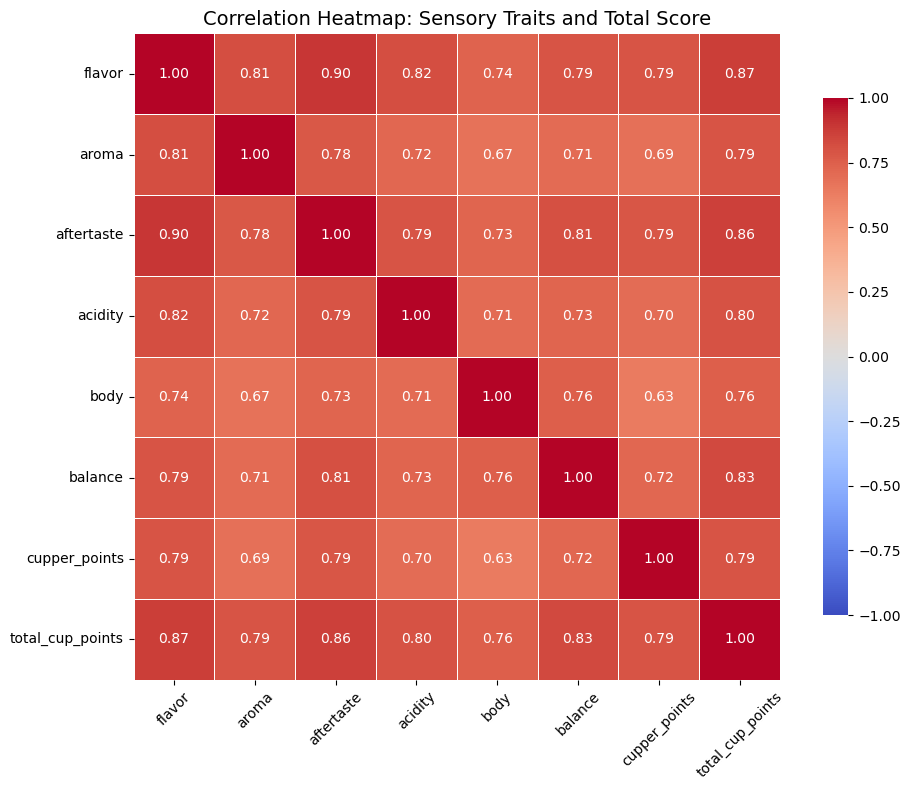

In [43]:
# Plot with seaborn
# Plot and save heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap: Sensory Traits and Total Score", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# Save the figure
plt.savefig("correlation_heatmap_sensory.png", dpi=300)

# Show the plot
plt.show()


In [51]:
sensory_cols = [
    'flavor', 'aroma', 'aftertaste',
    'acidity', 'body', 'balance',
    'cupper_points', 'total_cup_points'
]

In [56]:
# Use df_cqi and correct sensory column names
sensory_cols = [
    'flavor', 'aroma', 'aftertaste',
    'acidity', 'body', 'balance',
    'cupper_points', 'total_cup_points'
]

# Create correlation matrix
corr_matrix = df_cqi[sensory_cols].corr().round(2)

# Reshape correlation matrix to long format for Tableau
corr_long = corr_matrix.reset_index().melt(id_vars='index')
corr_long.columns = ['variable_1', 'variable_2', 'correlation']

# Save to Prepared_Data folder
corr_long.to_csv(
    "C:/Users/Chase/anaconda_projects/Exercise_6_Coffee/A6_Coffee/02_Data/Prepared_Data/quality_correlation_long.csv",
    index=False
)

## 8. Answering Questions

Questions that I was asking from the previous assignment:
1. Which coffee origins are associated with the highest average scores?
2. Do certain roast levels consistently receive higher scores?
3. Are there roaster locations that produce more top-rated coffees than others
4. Do coffees from specific countries or regions tend to have distinct roast levels or agtron scores?
5. Are there geographic patterns in pricing or scoring across roaster locations?
6. Which countries have the most roasters?
7. Do coffees from certain origins command higher prices and is that justified by score?
8. Do certain roast levels trend higher in score across the dataset?
9. Are certain origins becoming more popular over time?
10. Are lighter or darker roasts becoming more common?

#### Questions Answered

Question 2: Running the analysis and looking at Box Plot 1- Roast Level vs Flavor, I can see that the medium and medium-dark roasts tend to cluster around the higher median flavor scores. Lighter and medium roasts show more variability, some with high scores but also wider spread out. Correlation score at =0,32 suggests there's a moderate negative correlation between roast level and flavor score.

Question 8: Looking at the analysis and Box Plot 1- Roast Level vs Flavor, medium and medium dark roasts have the highest median scores. These categories also show tight interquartile ranges, suggesting consistency. Light and medium light roasts have wider spreads and a few high scores. Dark roast tend to score lower overall.


#### Unanswered Qestions

I am unable to answer the rest of the questions due to their cateorgaphy variables. This assignment was focused on numeric variables.

####  New Questions

- Which countries produce the highest and lowest scoring coffees by roast type?
- Which roast levels show the highest and most consistent cupper points?
- Which regions consistently outperform or underperform in sensory scoring?

## 9. Hypotheses to Test Later

1. Medium to medium-dark roast levels that yield the highest cupper scores are more likely to come from top-producing countries or regions.
2. Coffees with midrange agtron values (45–75) and medium roast levels show the lowest variance in flavor and acidity scores.
3.  Flavor, aroma, and aftertaste are the strongest predictors of total score, and their influence is amplified in medium roast profiles.
4.  Coffees with higher moisture content and medium roast levels score higher in flavor and cupper points than those with lower moisture content.
5.  Among high-scoring coffees, medium roast levels show the most consistent agtron values, suggesting tighter roast control.
6.  Flavor score is the strongest predictor of total cup points, outperforming other sensory traits across all roast levels.

## 10. Export

In [63]:
# Export
df_variables.to_csv(r"C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\02_Data\Prepared_Data\6.2_Exploring_Relations.csv", index=False)